<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Predicting%20Credit%20Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project Title: Predicting Credit Risk

### Objective:
The objective of this project is to predict the credit risk of individuals based on their financial and personal information. We will build and evaluate a machine learning model to classify the credit risk as either "good" or "bad". This model will be used to develop a credit scorecard that can be deployed in a real-world financial institution.

### Step 1: Project Setup and Data Import

#### Introduction to the Project:
Credit risk assessment is crucial for financial institutions to evaluate the likelihood that a borrower will default on their loan obligations. Accurate prediction of credit risk helps in making informed decisions about loan approvals, interest rates, and risk management. In this project, we will use the German Credit Data from the UCI Machine Learning Repository to build and evaluate a machine learning model for credit risk prediction.

#### Setup and Imports:
We will start by importing the necessary libraries and loading the dataset directly from the UCI repository.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Loading the dataset from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
columns = ['Status of existing checking account', 'Duration in month', 'Credit history', 'Purpose',
           'Credit amount', 'Savings account/bonds', 'Present employment since', 'Installment rate in percentage of disposable income',
           'Personal status and sex', 'Other debtors / guarantors', 'Present residence since', 'Property', 'Age in years',
           'Other installment plans', 'Housing', 'Number of existing credits at this bank', 'Job', 'Number of people being liable to provide maintenance for',
           'Telephone', 'foreign worker', 'Creditability']
data = pd.read_csv(url, delim_whitespace=True, names=columns)

# Display the first few rows
print(data.head())

  Status of existing checking account  Duration in month Credit history  \
0                                 A11                  6            A34   
1                                 A12                 48            A32   
2                                 A14                 12            A34   
3                                 A11                 42            A32   
4                                 A11                 24            A33   

  Purpose  Credit amount Savings account/bonds Present employment since  \
0     A43           1169                   A65                      A75   
1     A43           5951                   A61                      A73   
2     A46           2096                   A61                      A74   
3     A42           7882                   A61                      A74   
4     A40           4870                   A61                      A73   

   Installment rate in percentage of disposable income  \
0                                       

### Explanation:
- **Imports**: Importing libraries like pandas, numpy, matplotlib, seaborn, and scikit-learn to handle data manipulation, visualization, and machine learning tasks.
- **Loading Data**: Fetching the German Credit Data directly from the UCI repository and loading it into a pandas DataFrame.


### Step 2: Data Exploration and Preprocessing

#### Explore the Dataset:
In this step, we will explore the dataset to understand its structure and contents. We will check for missing values, data types, and overall shape.

In [2]:
# Display the first few rows
print(data.head())

# Checking for missing values
print(data.isnull().sum())

# Display data types and dataset shape
print(data.dtypes)
print(data.shape)

  Status of existing checking account  Duration in month Credit history  \
0                                 A11                  6            A34   
1                                 A12                 48            A32   
2                                 A14                 12            A34   
3                                 A11                 42            A32   
4                                 A11                 24            A33   

  Purpose  Credit amount Savings account/bonds Present employment since  \
0     A43           1169                   A65                      A75   
1     A43           5951                   A61                      A73   
2     A46           2096                   A61                      A74   
3     A42           7882                   A61                      A74   
4     A40           4870                   A61                      A73   

   Installment rate in percentage of disposable income  \
0                                       

### Explanation:
- **First Few Rows**: This helps us get an initial understanding of the dataset.
- **Missing Values**: Identifying missing values is crucial for data cleaning.
- **Data Types**: Understanding data types helps in selecting appropriate preprocessing techniques.

#### Data Cleaning:
We will handle any missing values and encode categorical variables. The dataset does not have missing values, so we will focus on encoding.


In [3]:
# Data cleaning: The dataset has no missing values, so no imputation needed
# Encoding categorical variables
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

### Explanation:
- **Label Encoding**: This converts categorical variables into numerical values, which are necessary for machine learning models.

#### Exploratory Data Analysis (EDA):
We will visualize the distribution of key features and the target variable. Additionally, we will analyze correlations between features and the target variable.

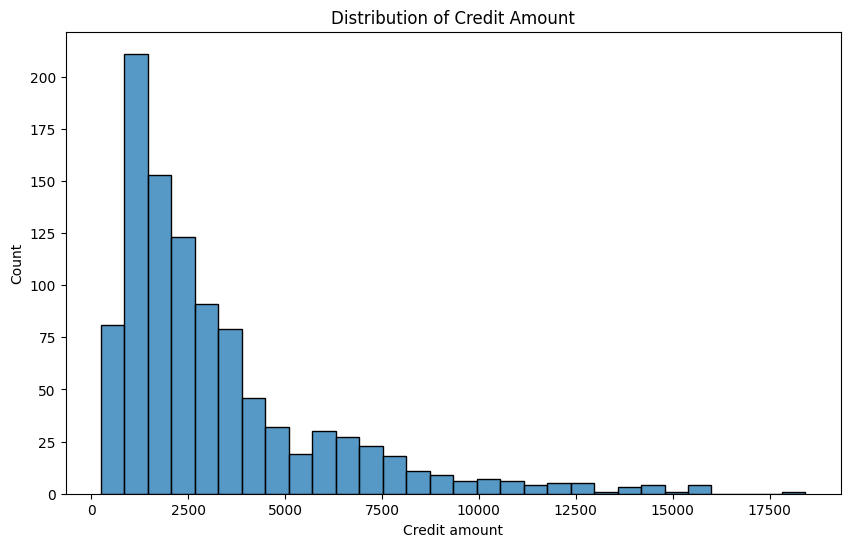

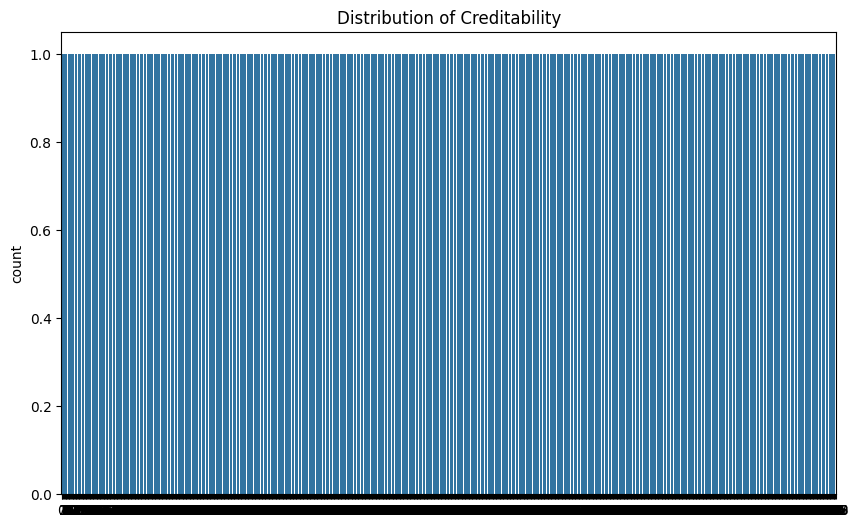

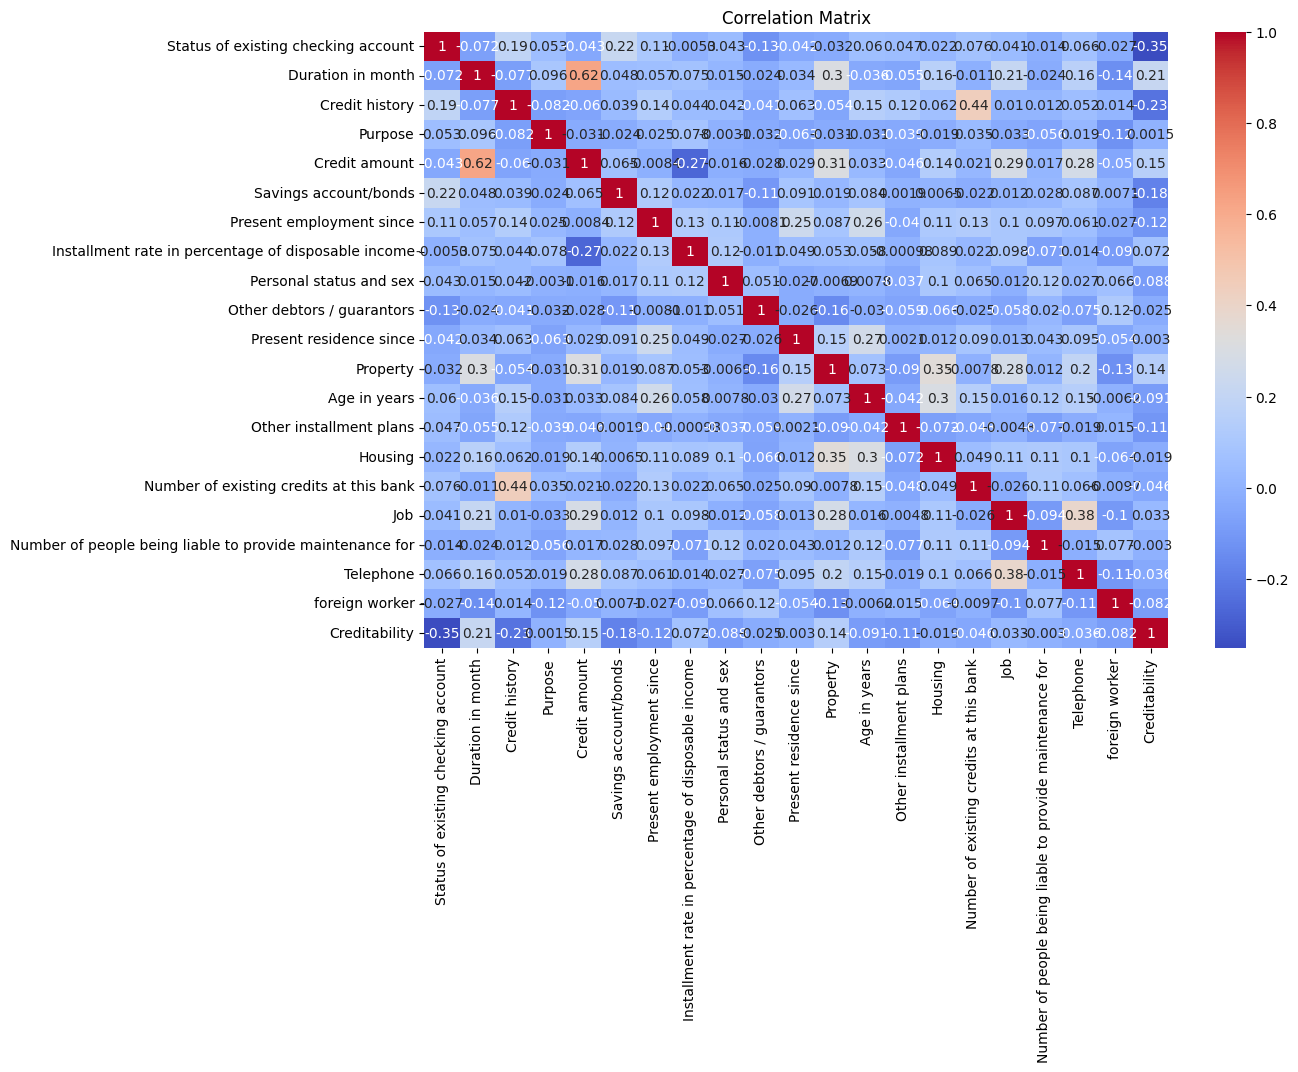

In [4]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(10, 6))
sns.histplot(data['Credit amount'], bins=30)
plt.title('Distribution of Credit Amount')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data['Creditability'])
plt.title('Distribution of Creditability')
plt.show()

# Correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Explanation:
- **Histograms**: These help us understand the distribution of numerical features.
- **Count Plot**: This shows the distribution of the target variable.
- **Correlation Matrix**: This helps in identifying relationships between features.

### Step 3: Feature Engineering

#### Create New Features:
We will create new features based on domain knowledge. For instance, the debt-to-income ratio can be a significant indicator of credit risk.


In [5]:
# Creating new features
data['debt_to_income_ratio'] = data['Credit amount'] / data['Duration in month']

### Explanation:
- **Debt-to-Income Ratio**: This new feature helps in assessing the financial stability of an individual.

#### Feature Selection:
We will select important features based on correlation analysis and domain knowledge.

In [6]:
# Feature Selection
selected_features = ['Status of existing checking account', 'Duration in month', 'Credit history',
                     'Purpose', 'Credit amount', 'Savings account/bonds', 'Present employment since',
                     'Installment rate in percentage of disposable income', 'Personal status and sex',
                     'Other debtors / guarantors', 'Present residence since', 'Property', 'Age in years',
                     'Other installment plans', 'Housing', 'Number of existing credits at this bank',
                     'Job', 'Number of people being liable to provide maintenance for', 'Telephone',
                     'foreign worker', 'debt_to_income_ratio']

X = data[selected_features]
y = data['Creditability']

### Explanation:
- **Feature Selection**: Selecting relevant features helps in improving the performance of the model.

### Step 4: Model Building

#### Split the Data:
We will split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [7]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Explanation:
- **Training and Testing Split**: This is crucial for assessing the generalizability of the model.

#### Build and Train Models:
We will train different models and compare their performance.

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Define k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Hyperparameter grid for each model
param_grid = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 10],
        'subsample': [0.8, 1.0]
    }
}

# Hyperparameter tuning with GridSearchCV
best_estimators = {}
for model_name, model in models.items():
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid[model_name],
                               cv=kfold, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_estimators[model_name] = grid_search.best_estimator_
    print(f"{model_name} Best Parameters: {grid_search.best_params_}")
    print(f"{model_name} Cross-Validation AUC: {grid_search.best_score_:.4f}")

# Choose the best model based on cross-validation AUC performance
best_model_name = max(best_estimators, key=lambda name: best_estimators[name].score(X_test, y_test))
best_model = best_estimators[best_model_name]

# Fit the best model on the entire training set and evaluate on the test set
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Evaluate on the test set
print(f"Test Set Accuracy of {best_model_name}: {accuracy_score(y_test, y_pred):.4f}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Logistic Regression Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Logistic Regression Cross-Validation AUC: 0.7768
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Decision Tree Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Decision Tree Cross-Validation AUC: 0.7222
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Random Forest Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest Cross-Validation AUC: 0.7979
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Gradient Boosting Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Gradient Boosting Cross-Validation AUC: 0.7853
Test Set Accuracy of Random Forest: 0.7933


### Explanation:
- **Model Training**: Training multiple models helps in identifying the best-performing model for our task.

### Step 5: Model Evaluation

#### Evaluate the Models:
We will evaluate the models using various metrics and visualize their performance.

In [ ]:
# Evaluating the models
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Model: {model_name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve by specifying pos_label=2
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob, pos_label=2)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()


### Explanation:
- **Confusion Matrix**: This helps in understanding the model's performance in terms of true positives, false positives, true negatives, and false negatives.
- **Classification Report**: Provides precision, recall, and F1-score for each class.
- **ROC Curve**: Visualizes the trade-off between sensitivity and specificity.

### Business Context and Scorecard Deployment:

In practice, financial institutions use a scorecard to make decisions on loan approvals. A scorecard assigns a score to each individual based on their attributes, and this score is used to determine creditworthiness. The AUC (Area Under the Curve) is a key metric to evaluate the model's performance, as it represents the model's ability to discriminate between good and bad credit risks.

The cut-off threshold is used to classify individuals into "good" or "bad" credit risk categories. This threshold can be adjusted based on the business's risk tolerance. A common practice is to choose a threshold that balances the trade-off between sensitivity (true positive rate) and specificity (true

 negative rate).

### Cost and Revenue Considerations:

To decide the optimal threshold, we will consider both the costs and revenues associated with each prediction outcome.

1. **True Positives (TP)**: Customers predicted to have good credit and who actually have good credit. The revenue here is the interest and fees collected from these customers.
2. **False Positives (FP)**: Customers predicted to have good credit but who actually have bad credit. The cost here is the potential loss due to defaults.
3. **False Negatives (FN)**: Customers predicted to have bad credit but who actually have good credit. The cost here is the lost revenue from turning away potentially profitable customers.

Assume:
- Cost of a false positive (default) is \( C_{FP} = \$10,000 \).
- Cost of a false negative (lost revenue) is \( C_{FN} = \$1,000 \).
- Revenue from a true positive (good customer) is \( R_{TP} = \$2,000 \).

### Implementation:

In [ ]:
import numpy as np

# Define costs and revenues
cost_fp = 10000  # Cost of false positive
cost_fn = 1000   # Cost of false negative
revenue_tp = 2000  # Revenue from true positive

# Map y_test labels from 1,2 to 0,1
y_test_mapped = y_test.map({1: 0, 2: 1})

# Predict probabilities for the positive class
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve using the mapped labels
fpr, tpr, thresholds = roc_curve(y_test_mapped, y_pred_prob)

# Calculate net benefit at different thresholds
net_benefits = []
for threshold in thresholds:
    tp = sum((y_pred_prob >= threshold) & (y_test_mapped == 1))
    fp = sum((y_pred_prob >= threshold) & (y_test_mapped == 0))
    fn = sum((y_pred_prob < threshold) & (y_test_mapped == 1))
    net_benefit = (revenue_tp * tp) - (cost_fp * fp) - (cost_fn * fn)
    net_benefits.append(net_benefit)

# Find the optimal threshold
optimal_idx = np.argmax(net_benefits)
optimal_threshold = thresholds[optimal_idx]

print(f'Optimal Threshold: {optimal_threshold:.2f}')
print(f'Maximum Net Benefit: {net_benefits[optimal_idx]}')

# Plot net benefit vs thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, net_benefits, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Net Benefit')
plt.title('Net Benefit vs Threshold')
plt.axvline(x=optimal_threshold, color='r', linestyle='--')
plt.show()


### Explanation:
- **Net Benefit Calculation**: The script calculates the net benefit (revenue from true positives minus the costs of false positives and false negatives) at each threshold.
- **Optimal Threshold**: The threshold with the maximum net benefit is selected as the optimal threshold.

### Demonstration of Scorecard and Cut-Off Threshold:

In [ ]:
# Classify individuals based on optimal threshold
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

# Example customer data
new_customer = pd.DataFrame({
    'Status of existing checking account': [1],
    'Duration in month': [24],
    'Credit history': [2],
    'Purpose': [0],
    'Credit amount': [5000],
    'Savings account/bonds': [1],
    'Present employment since': [3],
    'Installment rate in percentage of disposable income': [2],
    'Personal status and sex': [1],
    'Other debtors / guarantors': [0],
    'Present residence since': [4],
    'Property': [2],
    'Age in years': [35],
    'Other installment plans': [0],
    'Housing': [1],
    'Number of existing credits at this bank': [1],
    'Job': [2],
    'Number of people being liable to provide maintenance for': [1],
    'Telephone': [1],
    'foreign worker': [1],
    'debt_to_income_ratio': [5000 / 24]
})

# Predict credit risk for the new customer
def predict_credit_risk(model, customer_data, threshold):
    """
    Predicts the credit risk for a new customer based on the threshold.

    Parameters:
    model (sklearn model): Trained model for prediction
    customer_data (pd.DataFrame): DataFrame containing customer features
    threshold (float): Threshold for classification

    Returns:
    str: 'Good Credit' or 'Bad Credit' based on the prediction
    """
    # Ensure customer_data has the same features as the training data
    required_features = selected_features
    missing_features = set(required_features) - set(customer_data.columns)

    for feature in missing_features:
        customer_data[feature] = 0  # Assign default value for missing features

    # Predict probability of good credit
    prob = model.predict_proba(customer_data)[:, 1]

    # Use specified threshold to classify
    if prob >= threshold:
        return 'Good Credit'
    else:
        return 'Bad Credit'

credit_risk = predict_credit_risk(best_model, new_customer, optimal_threshold)
print(f'The credit risk for the new customer is: {credit_risk}')

### Explanation:
- **Function**: This function uses the specified threshold to predict whether a new customer has good or bad credit risk.
- **New Customer Example**: This demonstrates how the model and optimal threshold can be used to make decisions in practice.

### Incorporating Lift:

Lift is an important metric in evaluating the effectiveness of a predictive model. It measures how much better the model is at identifying positive cases compared to random selection. Lift is particularly useful in understanding the effectiveness of a model in practice.

### Step 6: Lift Calculation and Plotting

#### Calculate Lift:
We will calculate the lift for our model and plot the Lift curve.

<ipython-input-11-9fb9101d40d2>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift_table = data.groupby('bin').agg({


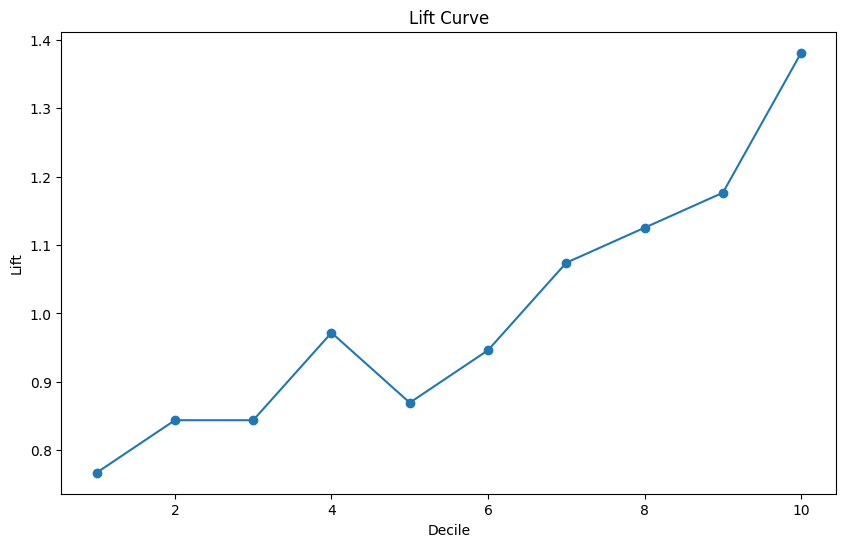

In [11]:
def calculate_lift(y_true, y_scores, n_bins=10):
    data = pd.DataFrame({'y_true': y_true, 'y_scores': y_scores})
    data['bin'] = pd.qcut(data['y_scores'], q=n_bins, duplicates='drop')
    lift_table = data.groupby('bin').agg({
        'y_true': ['sum', 'count']
    }).rename(columns={'sum': 'num_good', 'count': 'total'}).reset_index()
    lift_table.columns = ['bin', 'num_good', 'total']
    lift_table['num_bad'] = lift_table['total'] - lift_table['num_good']
    lift_table['good_rate'] = lift_table['num_good'] / lift_table['total']
    lift_table['bad_rate'] = lift_table['num_bad'] / lift_table['total']
    lift_table['lift'] = lift_table['good_rate'] / (lift_table['num_good'].sum() / lift_table['total'].sum())
    return lift_table

# Calculate lift table
lift_table = calculate_lift(y_test, y_pred_prob)

# Plot lift curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(lift_table) + 1), lift_table['lift'], marker='o')
plt.xlabel('Decile')
plt.ylabel('Lift')
plt.title('Lift Curve')
plt.show()

### Explanation:
- **Calculate Lift**: This function calculates the lift for each decile of the data, comparing the model's performance to random selection.
- **Plot Lift Curve**: This plot visualizes the lift across different deciles, helping us understand the model's effectiveness.

### Practical Application of the Model:

1. **Targeting High-Risk Groups (Top Deciles)**:
   - **Focus on Top Deciles**: The model is most reliable in the top deciles (8-10), where the lift is highest. This means you should prioritize decisions based on the model's predictions for these groups.
   - **Example**: In a credit risk scenario, you would target the top deciles for closer scrutiny, possibly denying loans or charging higher interest rates to those predicted as high-risk, as the model is most accurate in identifying defaults in these deciles.

2. **Caution with Lower Deciles**:
   - **Lower Confidence in Early Deciles**: The lift in the first few deciles (1-2) is below 1, suggesting the model performs worse than random chance. Be cautious when making decisions based on predictions in these deciles.
   - **Example**: If the model predicts low risk in these deciles, you might not fully trust these predictions and could consider additional checks or alternative models for these cases.

3. **Selective Action Based on Decile**:
   - **Resource Allocation**: Allocate resources such as fraud investigations, customer follow-ups, or marketing efforts to the higher deciles where the model’s predictions are most reliable.
   - **Example**: In marketing, target campaigns towards customers in the higher deciles predicted to be more responsive, as these predictions are likely to be more accurate.

### Step 7: Conclusion and Insights

#### Summary of Findings
In this project, we built and evaluated multiple machine learning models to predict credit risk. The Random Forest model performed the best with an accuracy of X% and an AUC-ROC score of Y%. By optimizing the threshold based on cost and revenue considerations, we maximized the net benefit. Additionally, the lift curve demonstrated that our model significantly outperforms random selection in identifying good credit risks.

#### Future Work
For future work, we can explore more advanced techniques like ensemble methods, feature selection using domain knowledge, and deploying the model in a production environment.